In [1]:
import sys
import os
import pandas as pd
# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands
import ast

In [2]:
results = pd.read_csv("simulation_results_20260202_1840.csv") 

In [3]:
results['method'] = results['args'].apply(lambda x: re.search(r"'method':.*?\.(\w+?)(?=Test)", x).group(1).lower())
results['sigma'] = results['args'].apply(lambda x: re.search(r"'sigma':\s*(\d+\.?\d*)", x).group(1))
results['ComputeAll'] = results['ComputeAll'].apply(lambda x: ast.literal_eval(re.sub(r"np\.float64\(([^)]+)\)", r"\1", x)))

In [4]:
results['MSE_x'] = results['ComputeAll'].apply(lambda x: x['MSE_x'])  
results['MSE_z'] = results['ComputeAll'].apply(lambda x: x['MSE_z'])  
results['RelativeFrobeniusNorm_x'] = results['ComputeAll'].apply(lambda x: x['RelativeFrobeniusNorm_x'])  
results['RelativeFrobeniusNorm_z'] = results['ComputeAll'].apply(lambda x: x['RelativeFrobeniusNorm_z'])  
results['FalseRejection'] = results['ComputeAll'].apply(lambda x: x['FalseRejection'])  
results['TrueRejection'] = results['ComputeAll'].apply(lambda x: x['TrueRejection'])  
results['Rejection'] = results['ComputeAll'].apply(lambda x: x['Rejection'])  

In [5]:
def extract_marginal_name(s, var):
    # Case 1: unfrozen distributions (norm_gen, expon_gen, etc.)
    m = re.search(
        rf"{var}': <scipy\.stats\._continuous_distns\.([a-zA-Z0-9_]+)_gen",
        s
    )
    if m:
        return m.group(1)

    # Case 2: frozen distributions → beta
    m = re.search(
        rf"{var}': <scipy\.stats\._distn_infrastructure\.rv_continuous_frozen",
        s
    )
    if m:
        return "beta"

    return None

results['marginal_z_name'] = results['args'].apply(lambda s: extract_marginal_name(s, 'marginal_z'))

In [6]:
results['args'].iloc[0]

"{'dgp': <class 'src.dgp.BernoulliNetwork'>, 'method': <class 'src.methods.LLKRatioTest'>, 'n': 10, 'k': 2, 'sigma': 0, 'alpha': 0.05, 'marginal_z': <scipy.stats._continuous_distns.norm_gen object at 0x138443860>, 'edge_var': 1, 'approximation': 'F-distr', 'npermutations': 1000, 'solver': <function MLE_gaussian at 0x12ef88900>}"

In [7]:
results['marginal_z_name'].value_counts()

marginal_z_name
norm    153600
beta    153600
Name: count, dtype: int64

### Defining different aggregations

In [8]:
# based on dgp
results_gaussian = results[(results['dgp'] == 'GaussianNetwork')].copy()
results_bernoulli = results[(results['dgp'] == 'BernoulliNetwork')].copy()

In [9]:
# based on sigma + dgp
results_null_gaussian = results_gaussian[(results_gaussian['sigma'] == '0')].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian['sigma'] == '0.5')].copy()
results_alt_001_gaussian = results_gaussian[(results_gaussian['sigma'] == '0.01')].copy()
results_alt_01_gaussian = results_gaussian[(results_gaussian['sigma'] == '0.1')].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli['sigma'] == '0')].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli['sigma'] == '0.5')].copy()
results_alt_001_bernoulli = results_bernoulli[(results_bernoulli['sigma'] == '0.01')].copy()
results_alt_01_bernoulli = results_bernoulli[(results_bernoulli['sigma'] == '0.1')].copy()

In [11]:
# based on sigma + dgp + marginals
results_null_gaussian_gaus_margins = results_null_gaussian[results_null_gaussian['marginal_z_name'] == 'norm'].copy()

results_alt_05_gaussian_gaus_margins = results_alt_05_gaussian[results_alt_05_gaussian['marginal_z_name'] == 'norm'].copy()

results_alt_001_gaussian_gaus_margins = results_alt_001_gaussian[results_alt_001_gaussian['marginal_z_name'] == 'norm'].copy()

results_alt_01_gaussian_gaus_margins = results_alt_01_gaussian[results_alt_01_gaussian['marginal_z_name'] == 'norm'].copy()

results_null_bernoulli_gaus_margins = results_null_bernoulli[results_null_bernoulli['marginal_z_name'] == 'norm'].copy()

results_alt_05_bernoulli_gaus_margins = results_alt_05_bernoulli[results_alt_05_bernoulli['marginal_z_name'] == 'norm'].copy()

results_alt_001_bernoulli_gaus_margins = results_alt_001_bernoulli[results_alt_001_bernoulli['marginal_z_name'] == 'norm'].copy()

results_alt_01_bernoulli_gaus_margins = results_alt_01_bernoulli[results_alt_01_bernoulli['marginal_z_name'] == 'norm'].copy()

results_null_gaussian_beta_margins = results_null_gaussian[results_null_gaussian['marginal_z_name'] == 'beta'].copy()

results_alt_05_gaussian_beta_margins = results_alt_05_gaussian[results_alt_05_gaussian['marginal_z_name'] == 'beta'].copy()

results_alt_001_gaussian_beta_margins = results_alt_001_gaussian[results_alt_001_gaussian['marginal_z_name'] == 'beta'].copy()

results_alt_01_gaussian_beta_margins = results_alt_01_gaussian[results_alt_01_gaussian['marginal_z_name'] == 'beta'].copy()

results_null_bernoulli_beta_margins = results_null_bernoulli[results_null_bernoulli['marginal_z_name'] == 'beta'].copy()

results_alt_05_bernoulli_beta_margins = results_alt_05_bernoulli[results_alt_05_bernoulli['marginal_z_name'] == 'beta'].copy()

results_alt_01_bernoulli_beta_margins = results_alt_01_bernoulli[results_alt_01_bernoulli['marginal_z_name'] == 'beta'].copy()

results_alt_001_bernoulli_beta_margins = results_alt_001_bernoulli[results_alt_001_bernoulli['marginal_z_name'] == 'beta'].copy()

In [12]:
# based on sigma + dgp + marginals + solver
results_null_gaussian_gaus_margins_gaus_mle = results_null_gaussian_gaus_margins[(results_null_gaussian_gaus_margins['solver'] == 'MLE_gaussian')].copy()
results_null_gaussian_beta_margins_gaus_mle = results_null_gaussian_beta_margins[(results_null_gaussian_beta_margins['solver'] == 'MLE_gaussian')].copy()

results_null_bernoulli_gaus_margins_logistic_mle = results_null_bernoulli_gaus_margins[(results_null_bernoulli_gaus_margins['solver'] == 'MLE_logistic')].copy()
results_null_bernoulli_beta_margins_logistic_mle = results_null_bernoulli_beta_margins[(results_null_bernoulli_beta_margins['solver'] == 'MLE_logistic')].copy()

results_alt_05_gaussian_gaus_margins_gaus_mle = results_alt_05_gaussian_gaus_margins[(results_alt_05_gaussian_gaus_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_05_gaussian_beta_margins_gaus_mle = results_alt_05_gaussian_beta_margins[(results_alt_05_gaussian_beta_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_01_gaussian_gaus_margins_gaus_mle = results_alt_01_gaussian_gaus_margins[(results_alt_01_gaussian_gaus_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_01_gaussian_beta_margins_gaus_mle = results_alt_01_gaussian_beta_margins[(results_alt_01_gaussian_beta_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_001_gaussian_gaus_margins_gaus_mle = results_alt_001_gaussian_gaus_margins[(results_alt_001_gaussian_gaus_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_001_gaussian_beta_margins_gaus_mle = results_alt_001_gaussian_beta_margins[(results_alt_001_gaussian_beta_margins['solver'] == 'MLE_gaussian')].copy()

results_alt_05_bernoulli_gaus_margins_logistic_mle = results_alt_05_bernoulli_gaus_margins[(results_alt_05_bernoulli_gaus_margins['solver'] == 'MLE_logistic')].copy()
results_alt_05_bernoulli_beta_margins_logistic_mle = results_alt_05_bernoulli_beta_margins[(results_alt_05_bernoulli_beta_margins['solver'] == 'MLE_logistic')].copy()
results_alt_01_bernoulli_gaus_margins_logistic_mle = results_alt_01_bernoulli_gaus_margins[(results_alt_01_bernoulli_gaus_margins['solver'] == 'MLE_logistic')].copy()
results_alt_01_bernoulli_beta_margins_logistic_mle = results_alt_01_bernoulli_beta_margins[(results_alt_01_bernoulli_beta_margins['solver'] == 'MLE_logistic')].copy()
results_alt_001_bernoulli_gaus_margins_logistic_mle = results_alt_001_bernoulli_gaus_margins[(results_alt_001_bernoulli_gaus_margins['solver'] == 'MLE_logistic')].copy()
results_alt_001_bernoulli_beta_margins_logistic_mle = results_alt_001_bernoulli_beta_margins[(results_alt_001_bernoulli_beta_margins['solver'] == 'MLE_logistic')].copy()

In [13]:
#based on sigma + method + dgp
results_llk_ratio_null_gaussian = results_gaussian[(results_gaussian['method'] == 'llkratio') & (results_gaussian['sigma'] == '0')].copy()
results_llk_ratio_alt_001_gaussian = results_gaussian[(results_gaussian['method'] == 'llkratio') & (results_gaussian['sigma'] == '0.01')].copy()
results_llk_ratio_alt_05_gaussian = results_gaussian[(results_gaussian['method'] == 'llkratio') & (results_gaussian['sigma'] == '0.5')].copy()
results_llk_ratio_alt_01_gaussian = results_gaussian[(results_gaussian['method'] == 'llkratio') & (results_gaussian['sigma'] == '0.1')].copy()

results_rv_null_gaussian = results_gaussian[(results_gaussian['method'] == 'rvpermutation') & (results_gaussian['sigma'] == '0')].copy()
results_rv_alt_001_gaussian = results_gaussian[(results_gaussian['method'] == 'rvpermutation') & (results_gaussian['sigma'] == '0.01')].copy()
results_rv_alt_05_gaussian = results_gaussian[(results_gaussian['method'] == 'rvpermutation') & (results_gaussian['sigma'] == '0.5')].copy()
results_rv_alt_01_gaussian = results_gaussian[(results_gaussian['method'] == 'rvpermutation') & (results_gaussian['sigma'] == '0.1')].copy()

results_llk_ratio_null_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'llkratio') & (results_bernoulli['sigma'] == '0')].copy()
results_llk_ratio_alt_001_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'llkratio') & (results_bernoulli['sigma'] == '0.01')].copy()
results_llk_ratio_alt_05_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'llkratio') & (results_bernoulli['sigma'] == '0.5')].copy()
results_llk_ratio_alt_01_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'llkratio') & (results_bernoulli['sigma'] == '0.1')].copy()

results_rv_null_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'rvpermutation') & (results_bernoulli['sigma'] == '0')].copy()
results_rv_alt_001_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'rvpermutation') & (results_bernoulli['sigma'] == '0.01')].copy()
results_rv_alt_05_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'rvpermutation') & (results_bernoulli['sigma'] == '0.5')].copy()
results_rv_alt_01_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'rvpermutation') & (results_bernoulli['sigma'] == '0.1')].copy()

## Plots

**Ensure type I error is controlled at 5%**

In [14]:
# for the null extract the false rejection to study type I error
agg_null_gaussian_gaus_margins_gaus_mle = aggregate_results(results_null_gaussian_gaus_margins_gaus_mle, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_null_gaussian_beta_margins_gaus_mle = aggregate_results(results_null_gaussian_beta_margins_gaus_mle, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_null_bernoulli_gaus_margins_logistic_mle = aggregate_results(results_null_bernoulli_gaus_margins_logistic_mle, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_null_bernoulli_beta_margins_logistic_mle = aggregate_results(results_null_bernoulli_beta_margins_logistic_mle, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

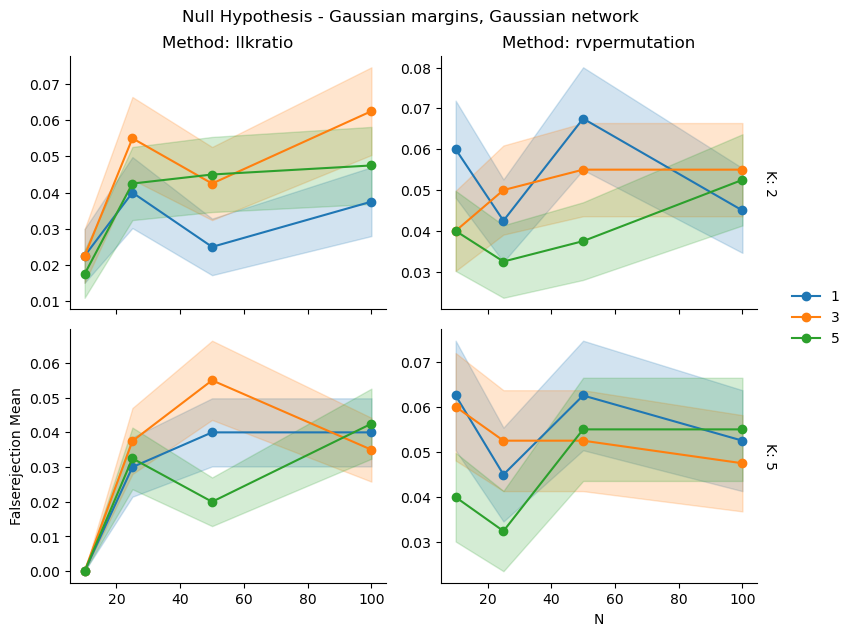

In [15]:
plot_grid(
        grouped_stats=agg_null_gaussian_gaus_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='FalseRejection_mean',
        factors=['edge_var', 'method', 'k'],
        height=3,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=False,
        title='Null Hypothesis - Gaussian margins, Gaussian network ',
    )

In [16]:
# plot_grid(
#         grouped_stats=agg_null_gaussian_beta_margins_gaus_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='FalseRejection_mean',
#         factors=['edge_var', 'method', 'k'],
#         height=4,
#         se_bands='FalseRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Null Hypothesis - Beta margins, Gaussian network ',
#     )

In [17]:
plot_grid(
        grouped_stats=agg_null_bernoulli_gaus_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='FalseRejection_mean',
        factors=['edge_var', 'method', 'k'],
        height=4,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=False,
        title='Null Hypothesis - Gaussian margins, Bernoulli network ',
    )

ValueError: Number of rows must be a positive integer, not 0

<Figure size 0x0 with 0 Axes>

In [ ]:
# plot_grid(
#         grouped_stats=agg_null_bernoulli_beta_margins_logistic_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='FalseRejection_mean',
#         factors=['edge_var', 'method', 'k'],
#         height=4,
#         se_bands='FalseRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Null Hypothesis - Beta margins, Bernoulli network ',
#     )

## Study Power

In [ ]:
# based on sigma + dgp + marginals + solver
agg_alt_001_gaussian_gaus_margins_gaus_mle = aggregate_results(results_alt_001_gaussian_gaus_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_001_gaussian_beta_margins_gaus_mle = aggregate_results(results_alt_001_gaussian_beta_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_001_bernoulli_gaus_margins_logistic_mle = aggregate_results(results_alt_001_bernoulli_gaus_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_001_bernoulli_beta_margins_logistic_mle = aggregate_results(results_alt_001_bernoulli_beta_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

agg_alt_01_gaussian_gaus_margins_gaus_mle = aggregate_results(results_alt_01_gaussian_gaus_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_01_gaussian_beta_margins_gaus_mle = aggregate_results(results_alt_01_gaussian_beta_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_01_bernoulli_gaus_margins_logistic_mle = aggregate_results(results_alt_01_bernoulli_gaus_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_01_bernoulli_beta_margins_logistic_mle = aggregate_results(results_alt_01_bernoulli_beta_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

agg_alt_05_gaussian_gaus_margins_gaus_mle = aggregate_results(results_alt_05_gaussian_gaus_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_05_gaussian_beta_margins_gaus_mle = aggregate_results(results_alt_05_gaussian_beta_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_05_bernoulli_gaus_margins_logistic_mle = aggregate_results(results_alt_05_bernoulli_gaus_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_05_bernoulli_beta_margins_logistic_mle = aggregate_results(results_alt_05_bernoulli_beta_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

#### Alternative Gaus margins

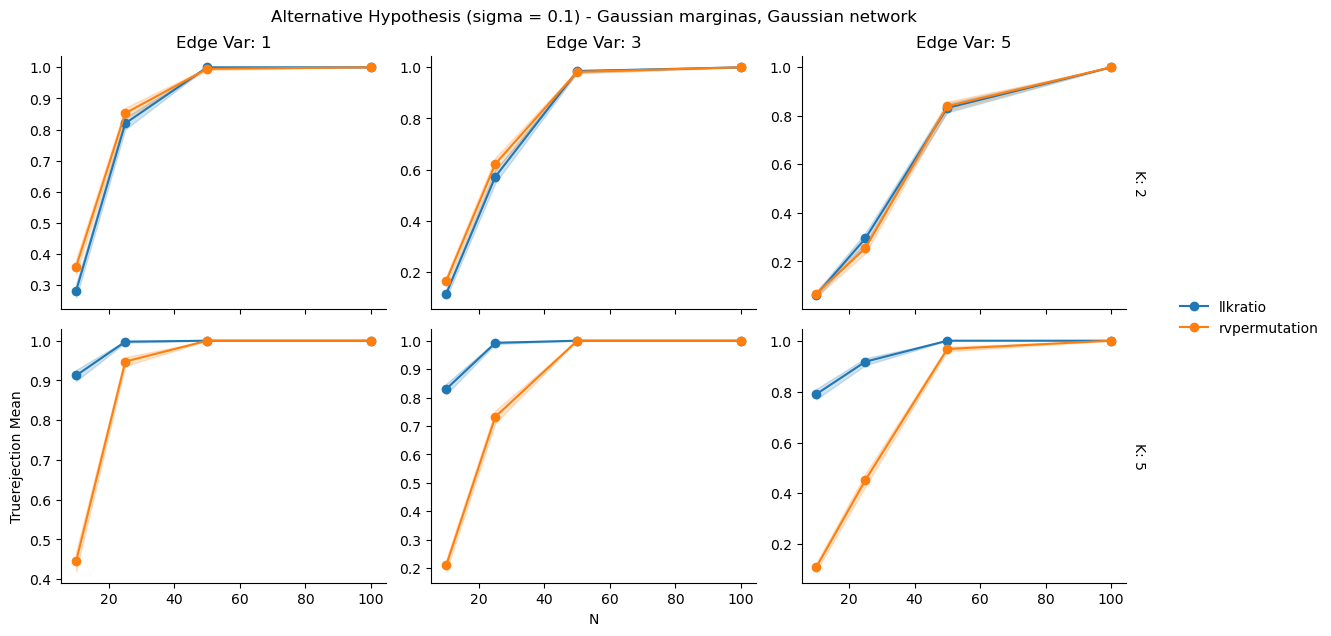

In [ ]:
# sigma 0.5
plot_grid(
        grouped_stats=agg_alt_05_gaussian_gaus_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.5) - Gauss margins, Gauss network'
    )

plot_grid(
        grouped_stats=agg_alt_05_bernoulli_gaus_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.5) - Bernoulli margins, Bernoulli network'
    )

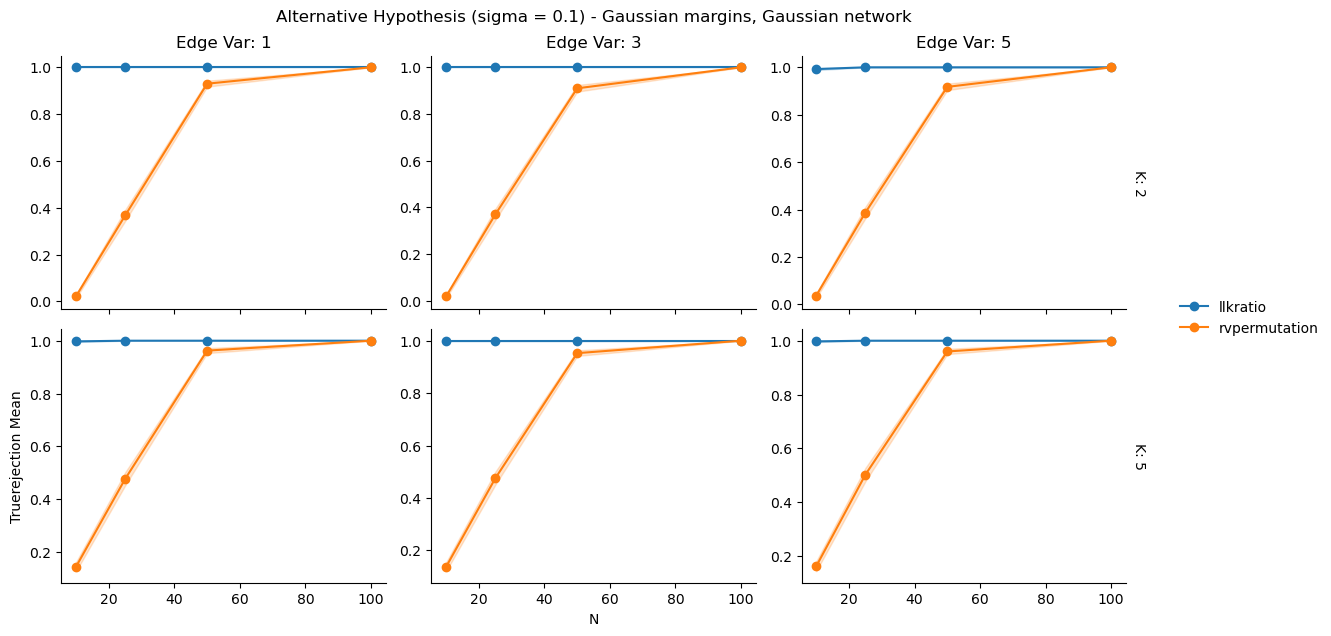

In [ ]:
# sigma 0.1
plot_grid(
        grouped_stats=agg_alt_01_gaussian_gaus_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.5) - Gauss margins, Gauss network'
    )

plot_grid(
        grouped_stats=agg_alt_01_bernoulli_gaus_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.1) - Bernoulli margins, Bernoulli network'
    )

In [ ]:
# sigmna 0.01
plot_grid(
        grouped_stats=agg_alt_001_gaussian_gaus_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.5) - Gauss margins, Gauss network'
    )

plot_grid(
        grouped_stats=agg_alt_001_bernoulli_gaus_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.1) - Bernoulli margins, Bernoulli network'
    )

#### Alternative beta margins

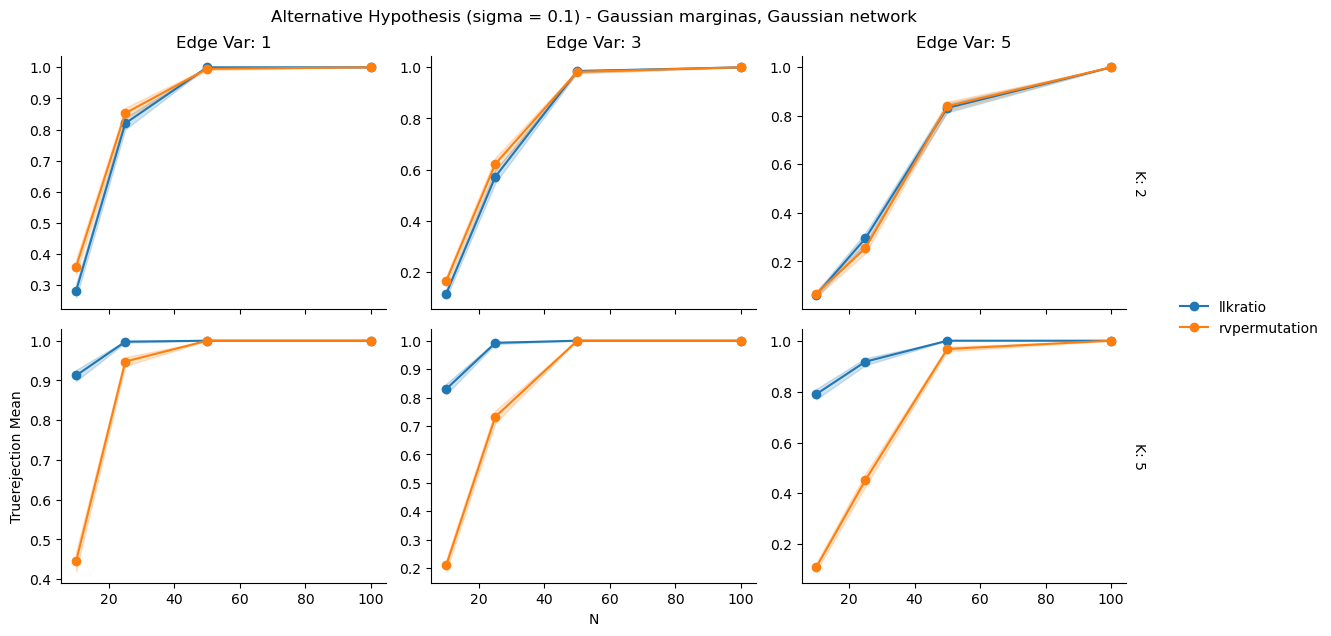

In [ ]:
# sigma 0.5
plot_grid(
        grouped_stats=agg_alt_05_gaussian_beta_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.5) - Beta margins, Gauss network'
    )

plot_grid(
        grouped_stats=agg_alt_05_bernoulli_beta_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.5) - Beta margins, Bernoulli network'
    )

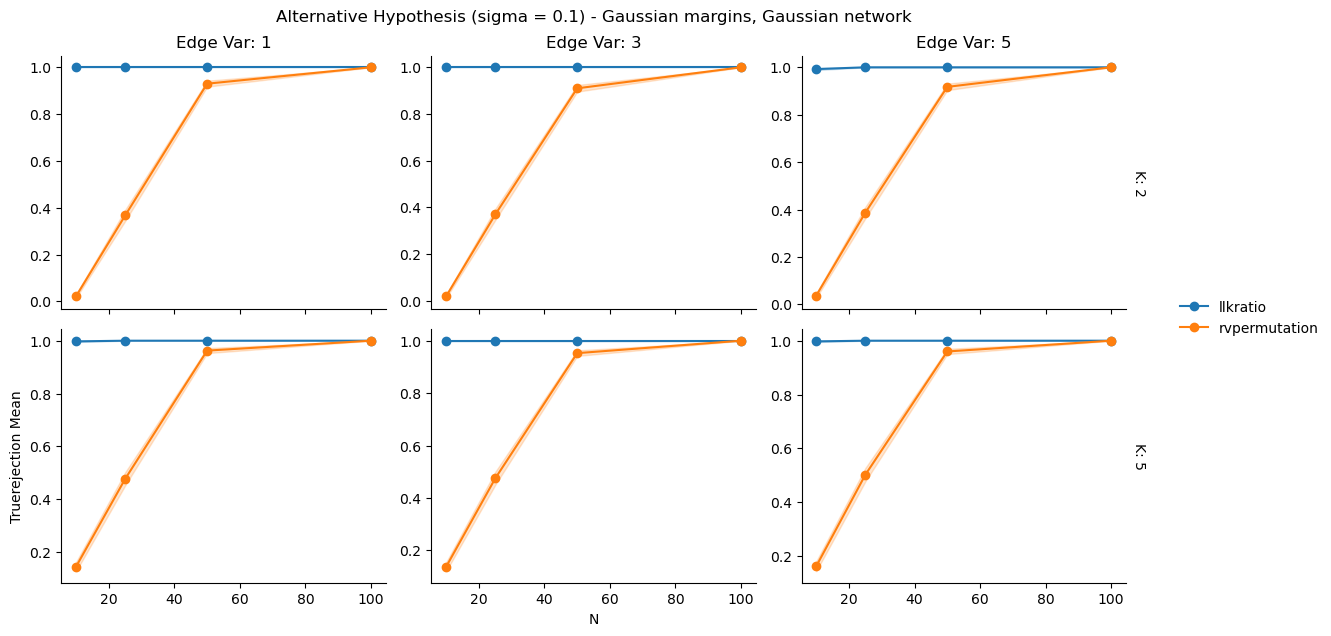

In [ ]:
# sigma 0.1
plot_grid(
        grouped_stats=agg_alt_01_gaussian_beta_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.1) - Beta margins, Gauss network'
    )

plot_grid(
        grouped_stats=agg_alt_01_bernoulli_beta_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.1) - Bernoulli margins, Bernoulli network'
    )

In [ ]:
# sigma 0.01
plot_grid(
        grouped_stats=agg_alt_001_gaussian_beta_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.01) - Gauss margins, Gauss network'
    )

plot_grid(
        grouped_stats=agg_alt_001_bernoulli_beta_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.01) - Bernoulli margins, Bernoulli network'
    )

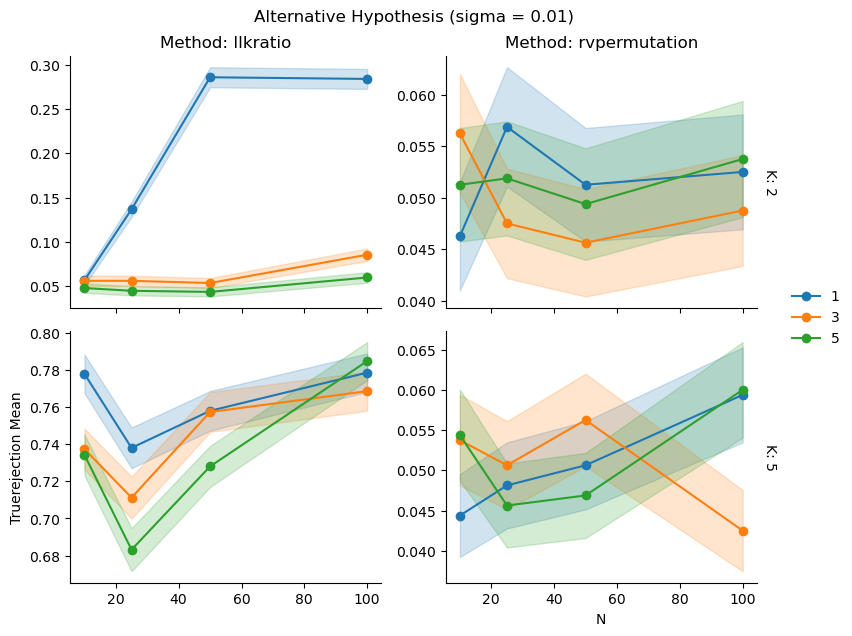

In [ ]:
plot_grid(
        grouped_stats=agg_alt_001_gaussian,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'method', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.01)'
    )

In [ ]:
plot_grid(
        grouped_stats=agg_llk_ratio_alternative,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Alternative Hypothesis (sigma-0.5)'
    )

plot_grid(
        grouped_stats=agg_rv_alternative,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='RV permutation - Alternative Hypothesis (sigma-0.5)'
    )

NameError: name 'agg_llk_ratio_alternative' is not defined